首先我们实现一个Transformer最核心的部分: 自注意力机制


经典线性代数教材是列向量优先时$Y=KQ$ 

但这里是行向量优先

行向量优先时$Y=QK^T$

两者在数学上完全等价

In [2]:
import torch
from torch import nn

class SelfAttention(nn.Module):
    def __init__(self, vocab_size, output_dim, d_model):
        super().__init__()
        self.d_model = d_model
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.out = nn.Linear(d_model, output_dim)
        self.attn_w = None  # 缓存最近一次的注意力权重用于可视化
    
    def forward(self, x):
        """
        x: (batch, seq_len)
        """
        x = self.embedding(x)  # (batch, seq_len, d_model)
        Q = self.w_q(x)
        K = self.w_k(x)
        V = self.w_v(x)
        # score: (batch, query, key) --- 序列内各位置之间的注意力, query为token位置, key为看的那个位置
        score = Q @ K.transpose(-2, -1) / self.d_model ** 0.5 # @等价于torch.matmul函数 为方便使用@
        attn_w = torch.softmax(score, dim=-1)
        self.attn_w = attn_w.detach()  # 缓存
        output = attn_w @ V          # (batch, seq_len, d_model)
        return self.out(output)      # (batch, seq_len, output_dim)


实验1: 

In [16]:
def generate_sample(batch_size, seq_len, K_RANGE, V_RANGE):

    key_vocab = torch.arange(*K_RANGE)
    val_vocab = torch.arange(*V_RANGE)

    keys = key_vocab[torch.randperm(len(key_vocab))[:seq_len]]
    keys = keys.repeat(batch_size,1)

    values = val_vocab[torch.randint(0,len(val_vocab),(batch_size,seq_len))]

    kv = torch.stack((keys, values), dim=2).reshape(batch_size, -1)

    idx = torch.randint(0, seq_len, (batch_size,))

    query = keys[torch.arange(batch_size), idx]

    x = torch.cat((kv, query.unsqueeze(1)), dim=1)

    y = values[torch.arange(batch_size), idx]

    return x.long(), y.long()

generate_sample(
    batch_size=64,
    seq_len=6,
    K_RANGE=(1,16),
    V_RANGE=(17,32)
)


(tensor([[ 6, 25,  8, 30,  4, 27,  3, 20, 14, 29,  7, 20,  4],
         [ 6, 26,  8, 30,  4, 20,  3, 21, 14, 29,  7, 23,  4],
         [ 6, 17,  8, 18,  4, 17,  3, 23, 14, 31,  7, 27,  3],
         [ 6, 25,  8, 31,  4, 25,  3, 29, 14, 31,  7, 27,  3],
         [ 6, 29,  8, 23,  4, 27,  3, 29, 14, 22,  7, 19,  7],
         [ 6, 26,  8, 19,  4, 26,  3, 19, 14, 23,  7, 28,  8],
         [ 6, 29,  8, 29,  4, 30,  3, 25, 14, 21,  7, 30, 14],
         [ 6, 18,  8, 29,  4, 29,  3, 31, 14, 19,  7, 28,  6],
         [ 6, 23,  8, 19,  4, 26,  3, 24, 14, 28,  7, 24, 14],
         [ 6, 25,  8, 29,  4, 31,  3, 24, 14, 29,  7, 29,  7],
         [ 6, 27,  8, 26,  4, 28,  3, 21, 14, 22,  7, 17,  6],
         [ 6, 31,  8, 25,  4, 24,  3, 18, 14, 20,  7, 22,  6],
         [ 6, 25,  8, 23,  4, 21,  3, 17, 14, 31,  7, 23,  6],
         [ 6, 24,  8, 18,  4, 17,  3, 30, 14, 19,  7, 25,  3],
         [ 6, 28,  8, 24,  4, 17,  3, 19, 14, 29,  7, 27,  3],
         [ 6, 31,  8, 27,  4, 26,  3, 19, 14, 27,  7, 2

# 实验1 找最大值下标

我们选一个任务来把这个最简单的自注意力用起来

输入：一堆乱序的数字 [10, 5, 80, 2]

目标：简单地把最大的数提取出来 80

我们来构造一个数据集测试这个模块的效果

In [13]:
def get_batch(batch, sql_len, low, high):
    x = torch.randint(low, high, (batch, sql_len), dtype=torch.long)  # (batch_size, n)
    y = torch.argmax(x, dim=-1)  # (batch_size,)
    return x, y
print(get_batch(2, 5, 0, 10))
epochs = 1000

model = SelfAttention(vocab_size=100, output_dim=1, d_model=4)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

model.train()
for i in range(epochs):
    train_x, train_y = get_batch(1024, 10, 0, 100)
    optimizer.zero_grad()
    pred = model(train_x).squeeze(-1)  # (batch, seq_len, 1) → (batch, seq_len)
    loss = criterion(pred, train_y)
    loss.backward()
    optimizer.step()
    if (i+1) % 100 == 0:
        print(f"Epoch {i+1}, Loss: {loss.item():.4f}")


(tensor([[2, 6, 4, 8, 6],
        [5, 7, 7, 3, 1]]), tensor([3, 1]))
Epoch 100, Loss: 0.1635
Epoch 200, Loss: 0.0546
Epoch 300, Loss: 0.0649
Epoch 400, Loss: 0.0599
Epoch 500, Loss: 0.0425
Epoch 600, Loss: 0.0360
Epoch 700, Loss: 0.0433
Epoch 800, Loss: 0.0530
Epoch 900, Loss: 0.0391
Epoch 1000, Loss: 0.0428


In [7]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Microsoft YaHei"
plt.rcParams["axes.unicode_minus"] = False

def plot_attention(attn_w, tokens=None, title="Batch", cmap="Blues"):
    # attn_w: (batch, T, T) 或 (T, T)
    if attn_w.dim() == 2:
        attn_w = attn_w.unsqueeze(0)
    attn_w = attn_w[:4].detach().cpu().float()   # 取前4个样本

    seq_len = attn_w.shape[1]
    if tokens is None:
        tokens = [str(i) for i in range(seq_len)]

    cell = seq_len * 0.5 + 0.5
    fig, axes = plt.subplots(2, 2, figsize=(cell * 2, cell * 2), constrained_layout=True)

    for n in range(4):
        ax = axes[n // 2][n % 2]
        im = ax.imshow(attn_w[n], cmap=cmap, vmin=0, vmax=1)
        ax.set_xticks(range(seq_len)); ax.set_xticklabels(tokens, rotation=45, ha="right", fontsize=7)
        ax.set_yticks(range(seq_len)); ax.set_yticklabels(tokens, fontsize=7)
        ax.set_title(f"{title} [{n}]", fontsize=9)
        for i in range(seq_len):
            for j in range(seq_len):
                val = attn_w[n, i, j].item()
                ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                        fontsize=6, color="white" if val > 0.6 else "black")

    plt.colorbar(im, ax=axes, fraction=0.02, pad=0.04)
    plt.show()

input : [64, 32, 16, 62, 84, 44, 13, 4, 65, 48]
pred  : [0, 1, 1, 0, 0, 0, 1, 1, 0, 0]
target: [4, 7]
------------------------------
input : [83, 32, 5, 14, 46, 26, 13, 10, 36, 72]
pred  : [0, 1, 1, 1, 0, 1, 1, 1, 1, 0]
target: [0, 2]
------------------------------
input : [5, 21, 54, 25, 26, 85, 12, 18, 31, 50]
pred  : [1, 1, 1, 1, 1, 0, 1, 1, 1, 1]
target: [5, 0]
------------------------------
input : [51, 23, 12, 14, 58, 74, 76, 83, 11, 12]
pred  : [1, 1, 1, 1, 1, 0, 0, 0, 1, 1]
target: [7, 8]
------------------------------


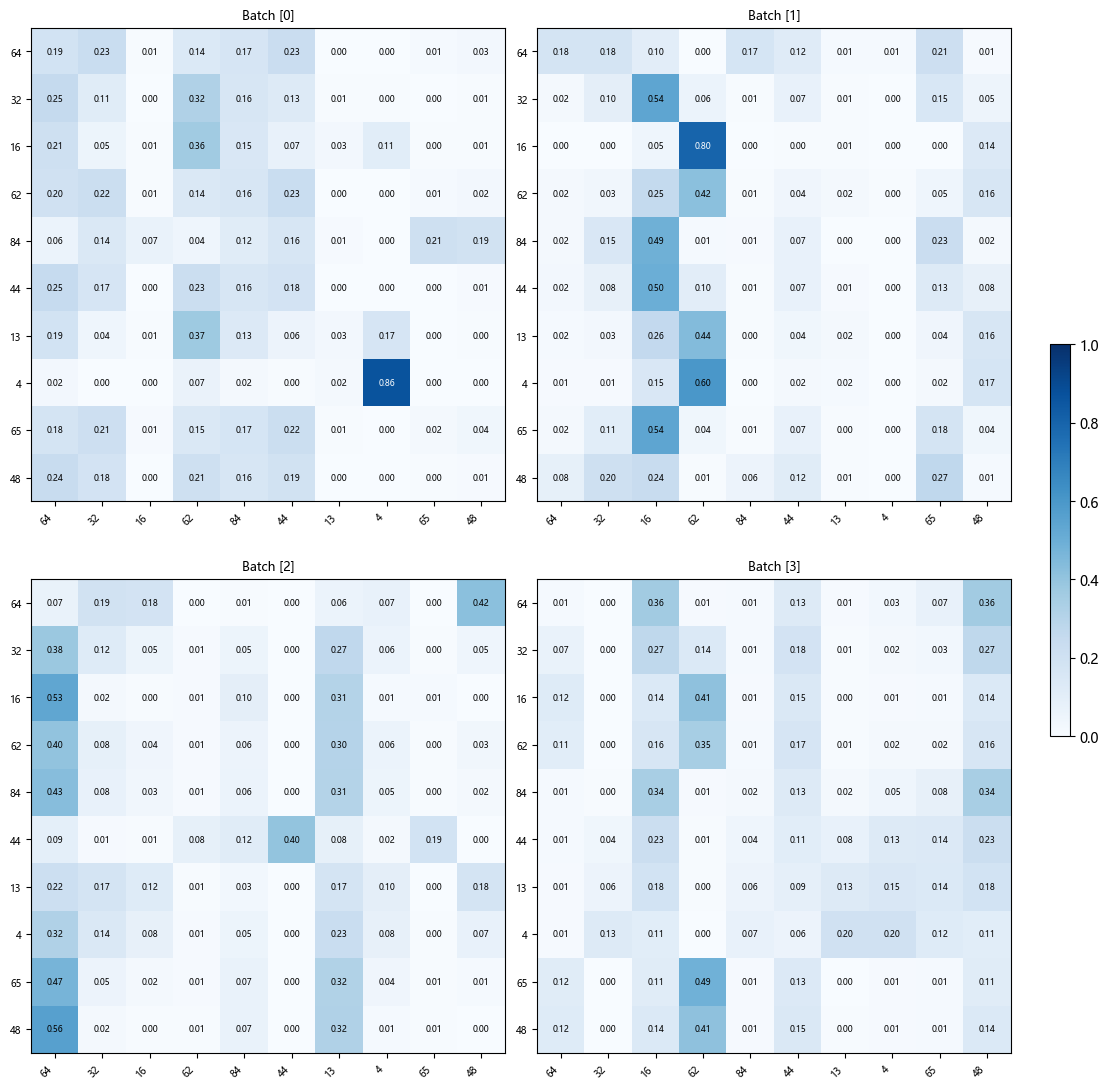

In [12]:
test_x, test_y = get_batch(4, 10, 1, 100)
sample_tokens = [str(v) for v in test_x[0].tolist()]

model.eval()
with torch.no_grad():
    logits = model(test_x) # (batch, seq_len, 1) → (batch, seq_len)
    pred = logits.argmax(dim=-1)  # (batch,) 取每行最大值的索引作为预测结果

    for i in range(test_x.size(0)):
        print(f"input : {test_x[i].tolist()}")
        print(f"pred  : {pred[i].tolist()}")
        print(f"target: {test_y[i].tolist()}")
        print("-" * 30)

    plot_attention(model.attn_w, tokens=sample_tokens)



In [4]:
def get_batch(batch, sql_len, low, high):
    train_x = torch.randint(low, high, (batch, sql_len), dtype=torch.long)  # (batch_size, n)
    max_y = torch.argmax(train_x, dim=-1)  # (batch_size,)
    min_y = torch.argmin(train_x, dim=-1)  # (batch_size,)
    return train_x, torch.stack([max_y, min_y], dim=-1)  # (batch_size, 2)

epochs = 1000

model = SelfAttention(vocab_size=100, output_dim=2, d_model=16)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

model.train()
for i in range(epochs):
    train_x, train_y = get_batch(1024, 10, 0, 100)
    # 将 (batch, len_n) → (batch, len_n, 1)，每个数字作为一个 token
    optimizer.zero_grad()
    pred = model(train_x)
    loss = criterion(pred, train_y)
    loss.backward()
    optimizer.step()
    if (i+1) % 100 == 0:
        print(f"Epoch {i+1}, Loss: {loss.item():.4f}")

Epoch 100, Loss: 0.1700
Epoch 200, Loss: 0.0716
Epoch 300, Loss: 0.0576
Epoch 400, Loss: 0.0596
Epoch 500, Loss: 0.0511
Epoch 600, Loss: 0.0479
Epoch 700, Loss: 0.0594
Epoch 800, Loss: 0.0492
Epoch 900, Loss: 0.0514
Epoch 1000, Loss: 0.0522


In [6]:
test_x, test_y = get_batch(3, 10, 1, 100)
model.eval()
with torch.no_grad():
    pred = model(test_x)
    for i in range(test_x.size(0)):
        print(f"input : {test_x[i].tolist()}")
        print(f"pred  : {pred[i].argmax(dim=-1).tolist()}")
        print(f"target: {test_y[i].tolist()}")
        print("-" * 30)


input : [1, 29, 77, 97, 15, 72, 20, 8, 15, 28]
pred  : [1, 1, 0, 0, 1, 0, 1, 1, 1, 1]
target: [3, 0]
------------------------------
input : [40, 59, 53, 99, 62, 7, 35, 17, 67, 76]
pred  : [1, 0, 1, 0, 0, 1, 1, 1, 0, 0]
target: [3, 5]
------------------------------
input : [37, 41, 52, 1, 69, 92, 63, 51, 99, 58]
pred  : [1, 1, 1, 1, 0, 0, 1, 1, 0, 1]
target: [8, 3]
------------------------------


# 实验2 序列查询

In [9]:
def get_seq_batch(batch, seq_len, vocab_size):
    seq = torch.randint(0, vocab_size, (batch, seq_len), dtype=torch.long)
    idx = torch.randint(0, seq_len, (batch,), dtype=torch.long)
    Q = torch.full((batch, 1), vocab_size, dtype=torch.long)  # 目标 token 是 vocab_size（即 high）这个特殊 token
    x = torch.cat([seq, Q, idx.unsqueeze(1)], dim=1)  # (batch, seq_len)
    y = seq[torch.arange(batch), idx]
    return x, y
print(get_seq_batch(2, 10, 10))
epochs = 1000

model = SelfAttention(vocab_size=11, output_dim=10, d_model=4)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

model.train()
for i in range(epochs):
    train_x, train_y = get_seq_batch(1024, 10, 10)
    optimizer.zero_grad()
    pred = model(train_x)[:, -1, :]
    loss = criterion(pred, train_y)
    loss.backward()
    optimizer.step()
    if (i+1) % 100 == 0:
        print(f"Epoch {i+1}, Loss: {loss.item():.4f}")


(tensor([[ 6,  7,  9,  2,  2,  9,  6,  9,  8,  5, 10,  5],
        [ 3,  5,  8,  9,  4,  1,  5,  4,  7,  0, 10,  6]]), tensor([9, 5]))
Epoch 100, Loss: 2.1238
Epoch 200, Loss: 2.1204
Epoch 300, Loss: 2.1145
Epoch 400, Loss: 2.1185
Epoch 500, Loss: 2.0752
Epoch 600, Loss: 2.0641
Epoch 700, Loss: 2.0583
Epoch 800, Loss: 2.0945
Epoch 900, Loss: 2.1030
Epoch 1000, Loss: 2.0594


real: tensor([6, 6, 3, 7])
pred: tensor([8, 1, 8, 7])


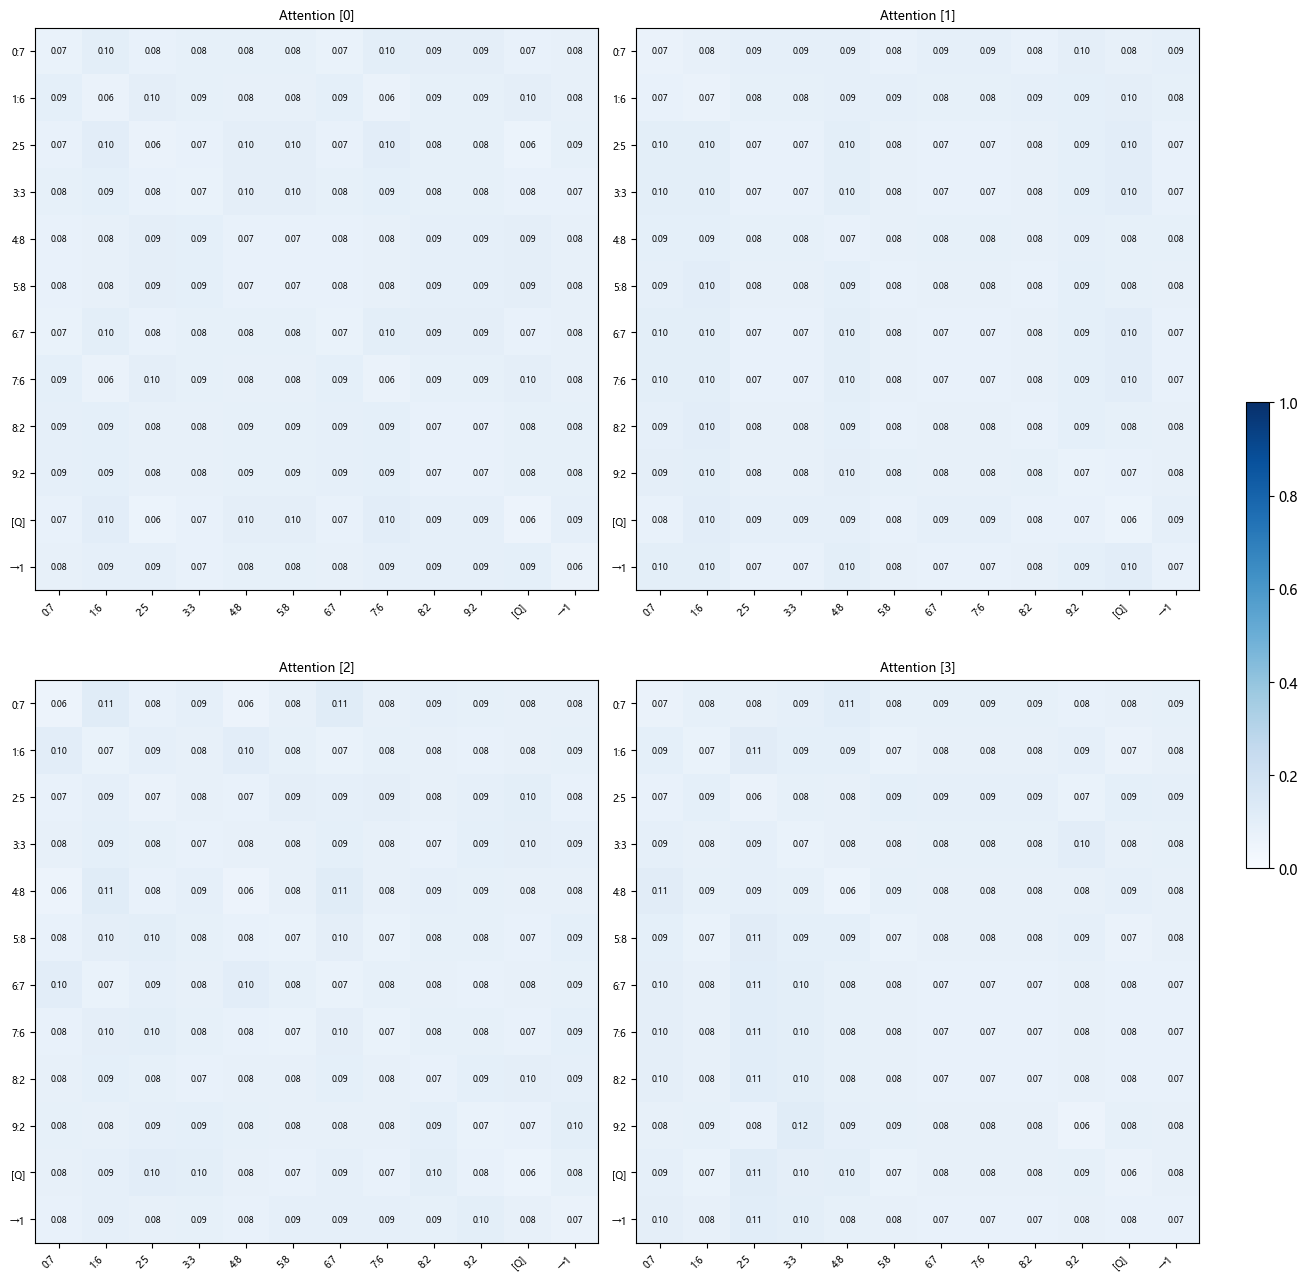

In [10]:
model.eval()
test_x, test_y = get_seq_batch(4, 10, 10)
values = test_x[0, :10].tolist()
q_idx  = test_x[0, -1].item()
query_labels = [f"{i}:{v}" for i, v in enumerate(values)] + ["[Q]", f"→{q_idx}"]
with torch.no_grad():
    pred = model(test_x)[:, -1, :]
    print("real:", test_y)
    print("pred:", pred.argmax(dim=-1))
    plot_attention(model.attn_w, tokens=query_labels, title="Attention")